# RACE — Avaliação e Contagem de Exercícios Físicos
## Máquina de Estados para Detecção de Repetições + Classificação Automática

Abordagem baseada em **limiares angulares com histerese** e **máquina de estados** para:

1. **Detecção de repetições** — transições `ESTENDIDO → CONTRAÍDO → ESTENDIDO`
2. **Qualidade de execução** — amplitude angular por repetição
3. **Classificação automática** — Random Forest sobre janelas temporais de 15 frames

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import savgol_filter
from enum import Enum

from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

OUTPUT_DIR = Path('files_output')
print('✓ Bibliotecas importadas')


✓ Bibliotecas importadas


## 1. Carregamento dos Dados

In [ ]:
ALL_FILES = [
    # Rafael
    ('1_min_flexao_full_5fps_flexao_rafael.csv',             'flexao',       'rafael'),
    ('2_min_agachamento_full_5fps_agachamento_rafael.csv',   'agachamento',  'rafael'),
    ('2_min_descanso_full_5fps_descanso.csv',                'descanso',     'rafael'),
    ('2_min_rosca_direta_full_5fps_rosca_biceps_rafael.csv', 'rosca_biceps', 'rafael'),
    # Paulo
    # ('paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv',  'agachamento',  'paulo'),
    # ('paulo_2_min_flexao_full_5fps_flexao_paulo.csv',            'flexao',       'paulo'),
    # ('paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv','rosca_biceps', 'paulo'),
    # Rodrigo
    # ('rodrigo_agachamento_full_5fps_agachamento.csv',             'agachamento',  'rodrigo'),
    # ('rodrigo_descanso_consolidado_full_5fps_descanso.csv',       'descanso',     'rodrigo'),
]

dfs = []
for fname, exercise_label, subject in ALL_FILES:
    path = OUTPUT_DIR / fname
    if path.exists():
        df = pd.read_csv(path)
        df['video_source'] = fname
        df['subject']      = subject
        dfs.append(df)
        print(f'  ✓ [{subject:7}] {exercise_label:15} — {len(df["frame"].unique())} frames')
    else:
        print(f'  ✗ NÃO ENCONTRADO: {fname}')

data_raw = pd.concat(dfs, ignore_index=True)

print('\nExtraindo ângulos...')
data = extract_angles_from_landmarks(data_raw)
subject_map = data_raw.drop_duplicates('video_source').set_index('video_source')['subject']
data['subject'] = data['video_source'].map(subject_map)

ANGLE_COLS = [
    'right_cotovelo', 'left_cotovelo',
    'right_ombro',    'left_ombro',
    'right_joelho',   'left_joelho',
    'right_quadril',  'left_quadril',
]

EXERCISE_COLORS = {
    'flexao':       '#e74c3c',
    'agachamento':  '#3498db',
    'rosca_biceps': '#2ecc71',
    'descanso':     '#95a5a6',
}

# ── Limiares da máquina de estados ───────────────────────────────────────────
# Cada exercício combina os ângulos esquerdo + direito ponderados pela visibilidade
# (bilateral_angle) antes de aplicar a máquina de estados.
# extended_thresh  : ângulo acima do qual a articulação está "estendida" (posição de descanso)
# contracted_thresh: ângulo abaixo do qual está "contraída" (posição de trabalho)
EXERCISE_CONFIG = {
    'flexao': {
        'joint':              'cotovelo',
        'extended_thresh':    130,   # braço quase estendido (posição inicial/final)
        'contracted_thresh':   90,   # cotovelo dobrado (próximo ao chão)
    },
    'agachamento': {
        'joint':              'joelho',
        'extended_thresh':    140,   # em pé
        'contracted_thresh':  100,   # agachado
    },
    'rosca_biceps': {
        'joint':              'cotovelo',
        'extended_thresh':    140,   # braço estendido (sinal real raramente passa de 140°)
        'contracted_thresh':   80,   # contração máxima
    },
}

exercises        = [ex for ex in ['flexao', 'agachamento', 'rosca_biceps', 'descanso']
                    if ex in data['exercise'].unique()]
active_exercises = [ex for ex in exercises if ex in EXERCISE_CONFIG]

print(f'\n✓ {data.shape[0]} frames  |  {data["video_source"].nunique()} vídeos')
print(f'\n  Exercícios:')
for ex, cnt in data.groupby('exercise').size().items():
    print(f'    {ex:15}: {cnt:5} frames')


  ✓ [rafael ] flexao          — 285 frames


  ✓ [rafael ] agachamento     — 887 frames
  ✓ [rafael ] descanso        — 714 frames
  ✓ [rafael ] rosca_biceps    — 603 frames

Extraindo ângulos...

✓ 2489 frames  |  4 vídeos

  Exercícios:
    agachamento    :   887 frames
    descanso       :   714 frames
    flexao         :   285 frames
    rosca_biceps   :   603 frames


## 3. Máquina de Estados para Contagem de Repetições

A máquina de estados usa **histerese** para evitar falsos acionamentos por ruído no sinal angular:

| Estado | Condição de entrada | Evento de saída |
|--------|---------------------|-----------------|
| `ESTENDIDO` | ângulo > `extended_thresh` | — |
| `CONTRAÍDO` | ângulo < `contracted_thresh` | — |
| Transição `CONTRAÍDO → ESTENDIDO` | ângulo > `extended_thresh` | **+1 repetição contada** |

> A histerese entre os dois limiares elimina falsas detecções causadas por pequenas variações do sinal.

In [ ]:
class RepState(Enum):
    UNKNOWN    = 0
    EXTENDED   = 1   # articulação estendida — posição de descanso/retorno
    CONTRACTED = 2   # articulação contraída — posição de trabalho/esforço


def bilateral_visibility_weighted_signal(grp, joint):
    """
    Combina os ângulos do lado direito e esquerdo de uma articulação usando
    a visibilidade de cada lado como peso — frame a frame.

    angle_bilateral[t] = (right[t] * w_right[t] + left[t] * w_left[t])
                         / (w_right[t] + w_left[t])

    Quando um lado é pouco visível ele contribui menos; quando ambos têm
    visibilidade zero o frame é preenchido com a média global.
    """
    r_col  = f'right_{joint}'
    l_col  = f'left_{joint}'
    rw_col = f'right_{joint}_visibility_weight'
    lw_col = f'left_{joint}_visibility_weight'

    r  = grp[r_col].values.astype(float)  if r_col  in grp.columns else np.full(len(grp), np.nan)
    l  = grp[l_col].values.astype(float)  if l_col  in grp.columns else np.full(len(grp), np.nan)
    wr = grp[rw_col].values.astype(float) if rw_col in grp.columns else np.ones(len(grp))
    wl = grp[lw_col].values.astype(float) if lw_col in grp.columns else np.ones(len(grp))

    wr = np.where(np.isnan(wr), 0.0, np.clip(wr, 0.0, 1.0))
    wl = np.where(np.isnan(wl), 0.0, np.clip(wl, 0.0, 1.0))

    # Zerar pesos de lados com ângulo inválido
    wr = np.where(np.isnan(r), 0.0, wr)
    wl = np.where(np.isnan(l), 0.0, wl)
    r  = np.nan_to_num(r, nan=0.0)
    l  = np.nan_to_num(l, nan=0.0)

    total_w  = wr + wl
    combined = np.where(total_w > 0, (r * wr + l * wl) / total_w, np.nan)
    # Preencher NaN residuais com a média global
    global_mean = np.nanmean(combined)
    combined    = np.where(np.isnan(combined), global_mean, combined)

    # Peso combinado médio (para plotagem)
    w_combined = np.where(total_w > 0, total_w / 2.0, 0.0)

    return combined, w_combined


def count_reps_state_machine(angle_series, extended_thresh, contracted_thresh):
    """
    Conta repetições com máquina de estados + histerese sobre o sinal
    bilateral ponderado por visibilidade.

    Transições:
      UNKNOWN/EXTENDED  →  CONTRACTED : ângulo < contracted_thresh
      CONTRACTED        →  EXTENDED   : ângulo > extended_thresh  (+1 rep)
    """
    signal = np.array(angle_series, dtype=float)
    state, rep_frames, state_series = RepState.UNKNOWN, [], []

    for i, angle in enumerate(signal):
        if state == RepState.UNKNOWN:
            if angle > extended_thresh:
                state = RepState.EXTENDED
            elif angle < contracted_thresh:
                state = RepState.CONTRACTED

        elif state == RepState.EXTENDED:
            if angle < contracted_thresh:
                state = RepState.CONTRACTED

        elif state == RepState.CONTRACTED:
            if angle > extended_thresh:
                state = RepState.EXTENDED
                rep_frames.append(i)   # ← repetição concluída

        state_series.append(state)

    return rep_frames, signal, state_series


# ── Executar para cada vídeo ──────────────────────────────────────────────────
results = []

for ex in active_exercises:
    cfg   = EXERCISE_CONFIG[ex]
    joint = cfg['joint']          # e.g. 'cotovelo' ou 'joelho'

    for vs, grp in data[data['exercise'] == ex].groupby('video_source'):
        grp        = grp.sort_values('frame').reset_index(drop=True)
        subject    = grp['subject'].iloc[0]
        duration_s = len(grp) / 5

        # ── Sinal bilateral ponderado por visibilidade ────────────────────────
        bilateral, w_combined = bilateral_visibility_weighted_signal(grp, joint)

        rep_frames, smooth_sig, state_seq = count_reps_state_machine(
            bilateral,
            extended_thresh=cfg['extended_thresh'],
            contracted_thresh=cfg['contracted_thresh'],
        )

        results.append({
            'exercise':     ex,
            'subject':      subject,
            'video_source': vs,
            'joint':        joint,
            'reps':         len(rep_frames),
            'duration_s':   duration_s,
            'reps_per_min': len(rep_frames) / duration_s * 60 if duration_s > 0 else 0,
            '_rep_frames':  rep_frames,
            '_smooth':      smooth_sig,
            '_raw':         grp[f'right_{joint}'].values if f'right_{joint}' in grp.columns else bilateral,
            '_weights':     w_combined,
            '_states':      state_seq,
            '_timestamps':  (grp['timestamp_s'].values
                             if 'timestamp_s' in grp.columns
                             else np.arange(len(grp)) / 5),
        })

df_results = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                            for r in results])

print('📊 Repetições detectadas (máquina de estados — ângulo bilateral ponderado por visibilidade):\n')
print(df_results[['exercise', 'subject', 'reps', 'duration_s', 'reps_per_min']]
      .to_string(index=False, float_format='{:.1f}'.format))


📊 Repetições detectadas (máquina de estados — ângulo bilateral ponderado por visibilidade):

    exercise subject  reps  duration_s  reps_per_min
      flexao  rafael    37        57.0          38.9
 agachamento  rafael    54       177.4          18.3
rosca_biceps  rafael    12       120.6           6.0


### Visualização das Repetições Detectadas

Fundo **azul** = estado ESTENDIDO &nbsp;|&nbsp; Fundo **vermelho** = estado CONTRAÍDO &nbsp;|&nbsp; **●** = repetição concluída

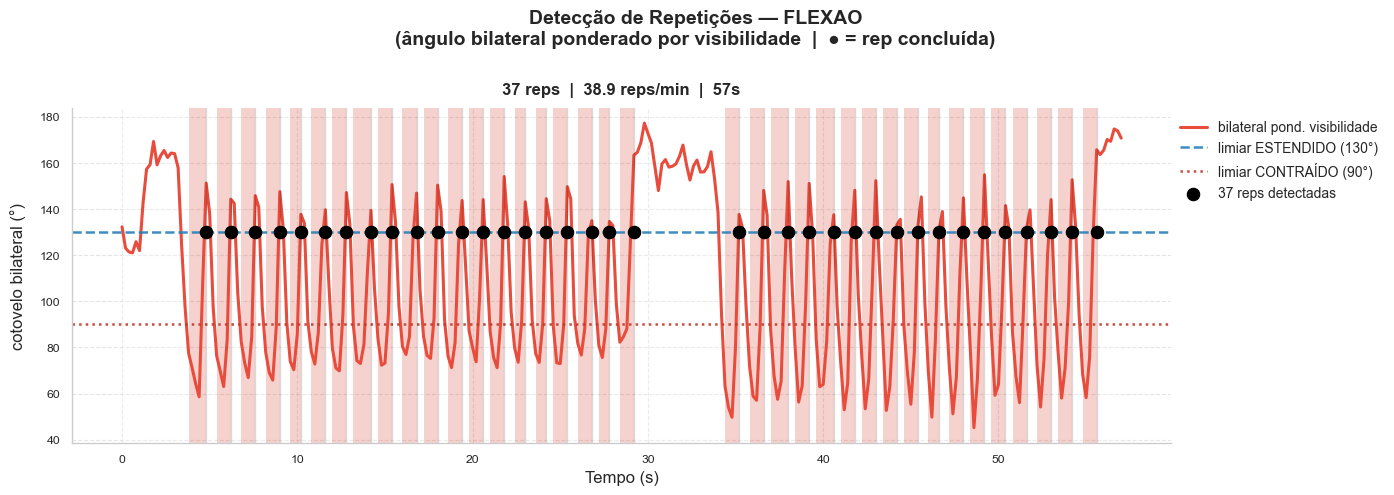

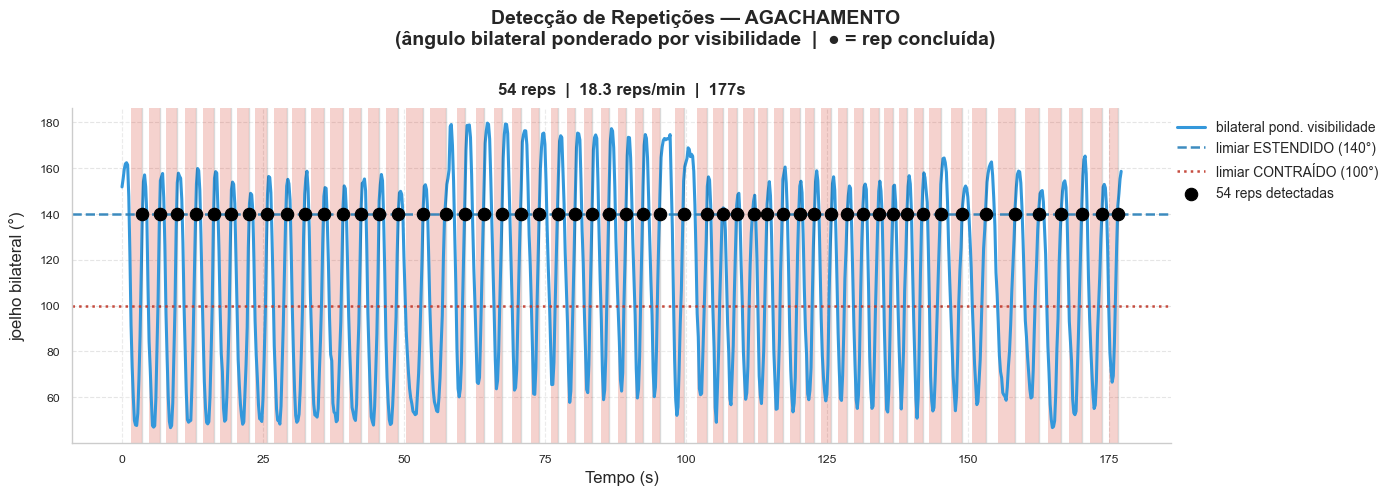

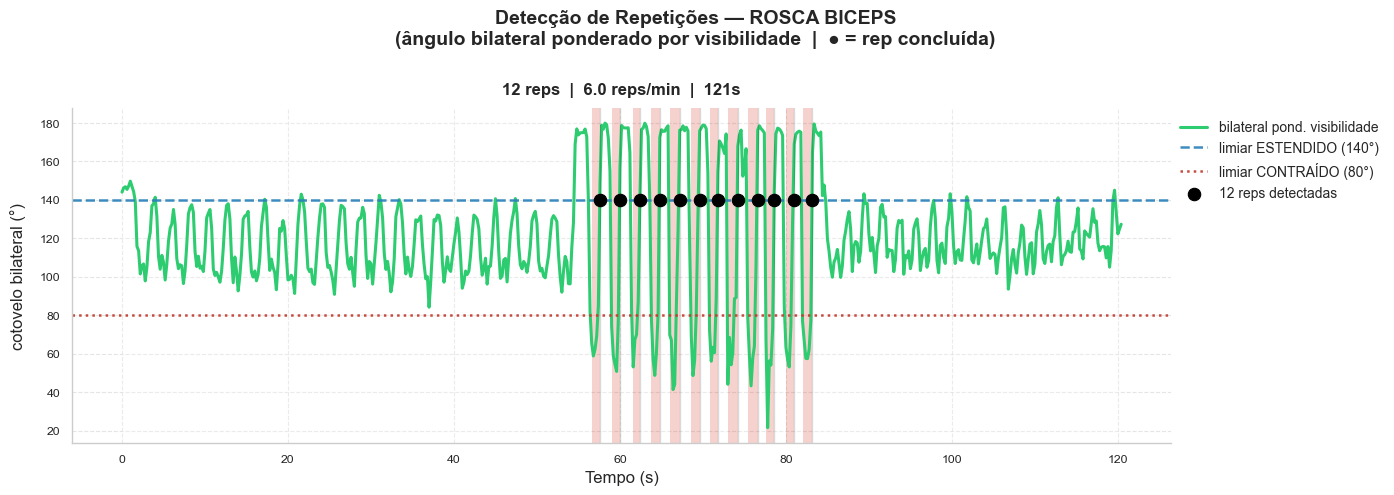

In [ ]:
sns.set_theme(style="whitegrid", context="paper")

STATE_COLORS = {
    RepState.EXTENDED:   "#FFFFFF",
    RepState.CONTRACTED: "#da4d3d",
    RepState.UNKNOWN:    '#e5e8e8',
}

from collections import defaultdict
results_by_exercise = defaultdict(list)
for r in results:
    results_by_exercise[r['exercise']].append(r)

for exercise, ex_results in results_by_exercise.items():
    n = len(ex_results)
    fig, axes = plt.subplots(n, 1, figsize=(14, 5 * n), squeeze=False)

    for i, r in enumerate(ex_results):
        ax = axes[i][0]

        t      = r['_timestamps']
        raw    = r['_raw']
        sm     = r['_smooth']
        rf     = r['_rep_frames']
        col    = EXERCISE_COLORS[r['exercise']]
        cfg    = EXERCISE_CONFIG[r['exercise']]
        states = r['_states']

        # Colorir fundo por estado
        seg_start, prev_state = 0, states[0]
        for j in range(1, len(states) + 1):
            cur = states[j - 1] if j < len(states) else None
            if cur != prev_state or j == len(states):
                sc = STATE_COLORS.get(prev_state, "#16a5a5")
                ax.axvspan(t[seg_start], t[min(j - 1, len(t) - 1)],
                           alpha=0.25, color=sc, linewidth=0)
                seg_start, prev_state = j - 1, cur


        ax.plot(t, sm,  color=col, alpha=1.0,  linewidth=2.2,
                label='bilateral pond. visibilidade')

        ax.axhline(cfg['extended_thresh'],   color='#2980b9', linestyle='--',
                   linewidth=1.8, alpha=0.9,
                   label=f'limiar ESTENDIDO ({cfg["extended_thresh"]}°)')
        ax.axhline(cfg['contracted_thresh'], color='#c0392b', linestyle=':',
                   linewidth=1.8, alpha=0.9,
                   label=f'limiar CONTRAÍDO ({cfg["contracted_thresh"]}°)')

        if rf:
            rf_arr = np.array(rf)
            y_thresh = np.full(len(rf_arr), cfg['extended_thresh'])
            ax.scatter(t[rf_arr], y_thresh, color='black', s=80, zorder=5,
                       label=f'{len(rf)} reps detectadas')
            for fi in rf:
                ax.axvline(t[fi], color='black', alpha=0.15, linewidth=1)

        ax.set_title( f"{len(rf)} reps  |  {r['reps_per_min']:.1f} reps/min  |  {r['duration_s']:.0f}s",
            fontsize=12, fontweight='bold', pad=10
        )
        ax.set_ylabel(f"{r['joint']} bilateral (°)", fontsize=12, labelpad=10)
        ax.set_xlabel('Tempo (s)', fontsize=12)
        ax.legend(fontsize=10, loc='upper right',bbox_to_anchor=(1.2, 1))
        ax.grid(True, alpha=0.5, linestyle='--')
        sns.despine(ax=ax)

    fig.suptitle(
        f'Detecção de Repetições — {exercise.upper().replace("_", " ")}\n'
        f'(ângulo bilateral ponderado por visibilidade  |  ● = rep concluída)',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


## 4. Avaliação da Qualidade das Repetições

**Amplitude angular** de cada repetição = ângulo máximo − ângulo mínimo dentro do intervalo da rep.  
Repetições com amplitude consistente indicam boa execução técnica.


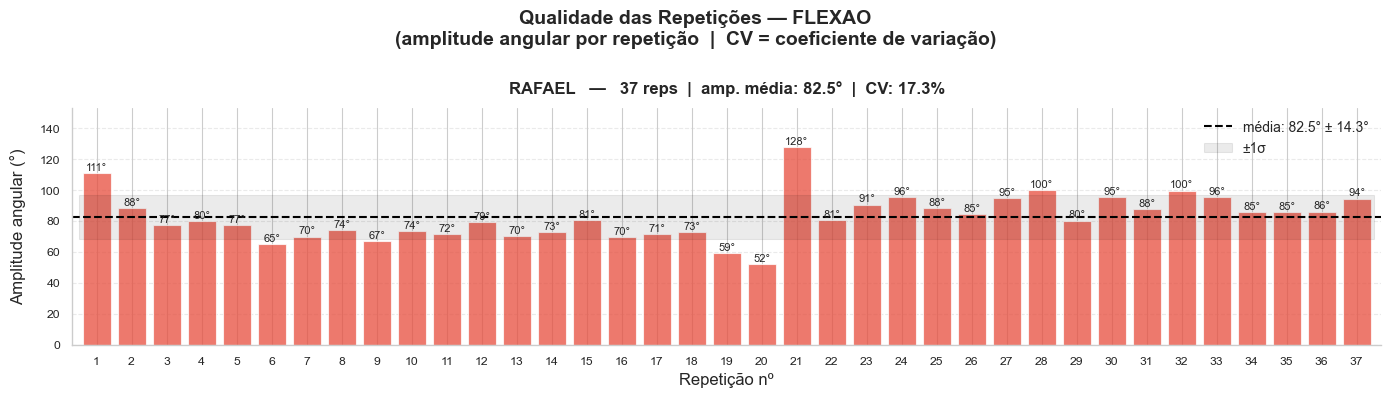

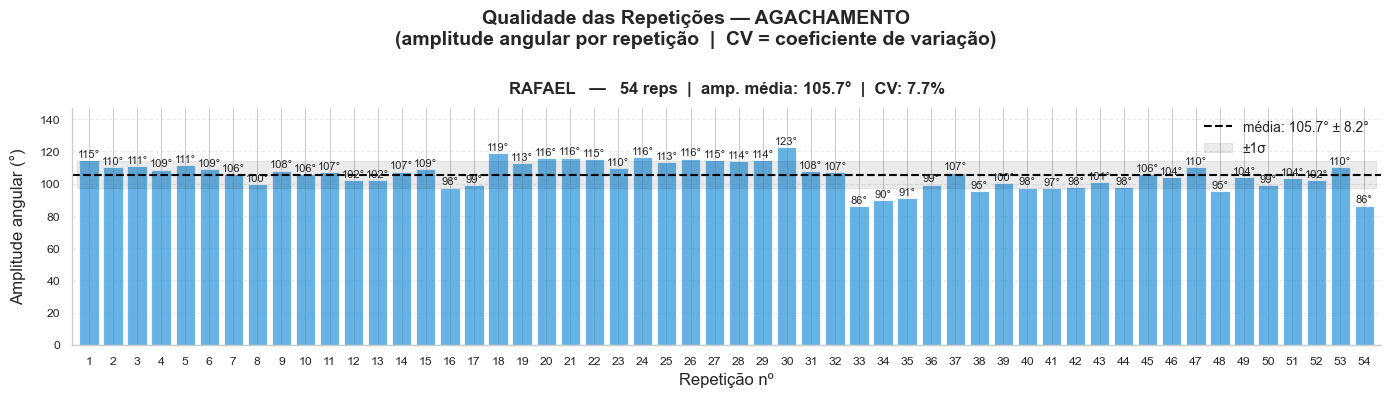

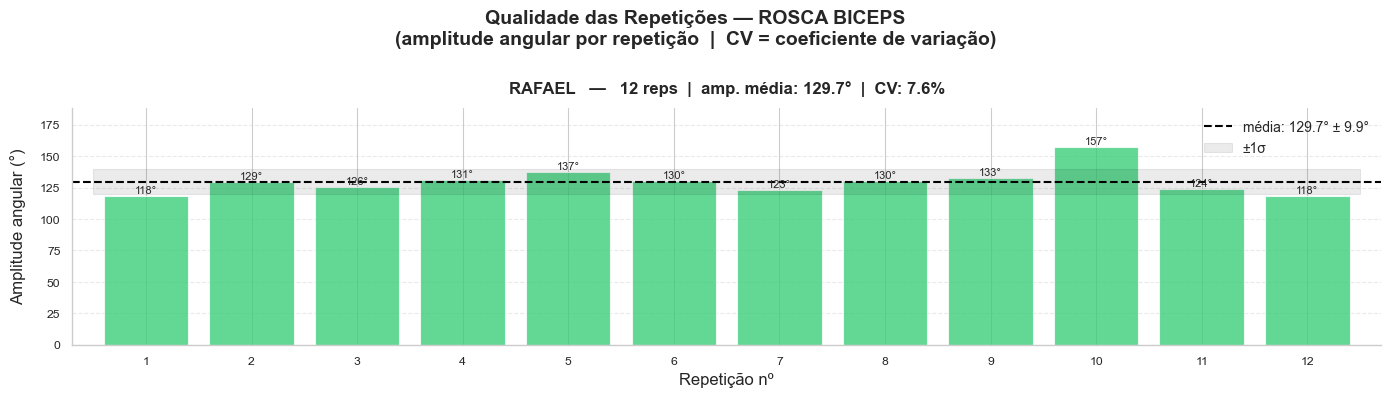

In [ ]:
sns.set_theme(style="whitegrid", context="paper")

for exercise, ex_results in results_by_exercise.items():
    n = len(ex_results)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), squeeze=False)
    col = EXERCISE_COLORS[exercise]

    for i, r in enumerate(ex_results):
        ax  = axes[i][0]
        sm  = r['_smooth']
        rf  = r['_rep_frames']
        t   = r['_timestamps']
        cfg = EXERCISE_CONFIG[r['exercise']]

        if len(rf) < 2:
            ax.text(0.5, 0.5, 'Repetições insuficientes para avaliação',
                    ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(f"{r['subject'].upper()}", fontsize=12, fontweight='bold')
            continue

        # Calcular amplitude de cada rep: intervalo entre rep[k-1] e rep[k]
        boundaries = [0] + rf
        amplitudes, rep_times, mins_vals, max_vals = [], [], [], []

        for k in range(1, len(boundaries)):
            seg = sm[boundaries[k - 1]: boundaries[k]]
            if len(seg) == 0:
                continue
            amp  = float(np.max(seg) - np.min(seg))
            tmed = float(t[boundaries[k]])
            amplitudes.append(amp)
            rep_times.append(tmed)
            mins_vals.append(float(np.min(seg)))
            max_vals.append(float(np.max(seg)))

        rep_nums  = np.arange(1, len(amplitudes) + 1)
        amp_mean  = np.mean(amplitudes)
        amp_std   = np.std(amplitudes)

        bars = ax.bar(rep_nums, amplitudes, color=col, alpha=0.75, edgecolor='white', linewidth=0.8)

        # Linha da média
        ax.axhline(amp_mean, color='black', linestyle='--', linewidth=1.5,
                   label=f'média: {amp_mean:.1f}° ± {amp_std:.1f}°')
        ax.fill_between([0.5, len(rep_nums) + 0.5],
                        amp_mean - amp_std, amp_mean + amp_std,
                        color='black', alpha=0.08, label='±1σ')

        # Anotação do valor em cada barra
        for bar_patch, amp_val in zip(bars, amplitudes):
            ax.text(bar_patch.get_x() + bar_patch.get_width() / 2,
                    bar_patch.get_height() + 0.5,
                    f'{amp_val:.0f}°', ha='center', va='bottom', fontsize=8)

        ax.set_title(
            f"{r['subject'].upper()}   —   "
            f"{len(amplitudes)} reps  |  amp. média: {amp_mean:.1f}°  |  CV: {amp_std/amp_mean*100:.1f}%",
            fontsize=12, fontweight='bold', pad=10
        )
        ax.set_xlabel('Repetição nº', fontsize=12)
        ax.set_ylabel('Amplitude angular (°)', fontsize=12, labelpad=10)
        ax.set_xticks(rep_nums)
        ax.set_xlim(0.3, len(rep_nums) + 0.7)
        ax.set_ylim(0, max(amplitudes) * 1.2)
        ax.legend(fontsize=10, loc='upper right', framealpha=0.92, edgecolor='#cccccc')
        ax.grid(True, alpha=0.4, linestyle='--', axis='y')
        sns.despine(ax=ax)

    fig.suptitle(
        f'Qualidade das Repetições — {exercise.upper().replace("_", " ")}\n'
        f'(amplitude angular por repetição  |  CV = coeficiente de variação)',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'images/qualidade_reps_{exercise}.png', dpi=150, bbox_inches='tight')
    plt.show()
